# What is a wet cell?

One day of U, V, W from raw GLORYS and from the Poisson-corrected `*b.nc`, side by side, so the
grid is visible cell by cell. Atlantic only - the Pacific is masked off in the corrected files
and is not used here.

The definitions, which is the whole point of the notebook:

| | |
|---|---|
| **T-cell** `k` is wet | `k + 1 <= mbathy`. It spans `gdepw_0[k]` to `gdepw_0[k+1]` on the axis Parcels uses. Its *true* thickness is `e3t_0[k]`, except the deepest wet one, which is the partial cell `e3t_ps`. |
| **U** at face `(k, j, i)` exists | if T-cells `(k,j,i)` and `(k,j,i+1)` are both wet. It is the velocity through that whole face - Parcels holds it constant over the cell's full depth range. |
| **W** at level `(k, j, i)` | sits on the **top face** of T-cell `k`. GLORYS stores it for `k = 0 .. mbathy-1` and leaves `k = mbathy` (the seabed) as NaN. |
| **dead wet cell** | `mbathy` says there is water, but the velocity file says 0. |

In [1]:
DAY = 1                                  # index into the January file

ZGR, HGR = "Zgr_cmesh2.nc", "Hgr_cmesh.nc"
GLORYS  = dict(U="U_1993-01.nc",  V="V_1993-01.nc",  W="W_1993-01.nc")
POISSON = dict(U="U_1993-01b.nc", V="V_1993-01b.nc", W="W_1993-01b.nc")

# transect across the Amazon shelf: fixed latitude, running offshore
TRANSECT_LAT = 2.0
TRANSECT_LON = (-51.0, -44.0)

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy import sparse
from scipy.sparse.csgraph import connected_components

SURF, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#dedcd6"
plt.rcParams.update({"font.size": 9, "axes.edgecolor": GRID, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2, "axes.facecolor": SURF,
    "figure.facecolor": SURF, "axes.titlecolor": INK})

## 1. Grid and masks

In [3]:
zgr = xr.open_dataset(ZGR).squeeze()
mbathy  = zgr.mbathy.values.astype(int)
gdepw_0 = zgr.gdepw_0.squeeze().values.astype("f8")     # cell EDGES, the axis Parcels uses
gdept_0 = zgr.gdept_0.squeeze().values.astype("f8")     # cell centres, where U,V are labelled
e3t_0   = zgr.e3t_0.squeeze().values.astype("f8")
e3t_ps  = zgr.e3t_ps.values.astype("f8")
lon2d, lat2d = zgr.nav_lon.values, zgr.nav_lat.values
ny, nx  = mbathy.shape
nz      = len(gdepw_0)
k3      = np.arange(nz)[:, None, None]

wet_t = (k3 + 1) <= mbathy                               # tmask: the mesh's definition of water
e3t   = np.where(k3 + 1 <= mbathy - 1, e3t_0[:, None, None], e3t_ps)
e3t   = np.where(wet_t, e3t, 0.0)
H     = e3t.sum(0)                                       # TRUE seabed depth (partial cells)
Hnom  = np.where(mbathy > 0, gdepw_0[np.clip(mbathy, 0, nz - 1)], 0.0)   # nominal seabed

# Atlantic = the largest connected body of water; the Pacific is excluded throughout
_oc = mbathy > 0
_id = np.full(_oc.shape, -1, np.int64); _id[_oc] = np.arange(_oc.sum())
_fe = _oc[:, :-1] & _oc[:, 1:]; _fn = _oc[:-1, :] & _oc[1:, :]
_r = np.concatenate([_id[:, :-1][_fe], _id[:-1, :][_fn]])
_c = np.concatenate([_id[:, 1:][_fe], _id[1:, :][_fn]])
_n, _lab = connected_components(
    sparse.coo_matrix((np.ones(_r.size), (_r, _c)), shape=(_oc.sum(),) * 2), directed=False)
_full = np.full(_oc.shape, -1); _full[_oc] = _lab
atlantic = _oc & (_full == np.bincount(_lab).argmax())

print(f"{ny} x {nx} x {nz};  {int(_oc.sum())} wet columns, {int(atlantic.sum())} in the Atlantic")
_frac = (e3t_ps / e3t_0[np.clip(mbathy - 1, 0, nz - 1)])[atlantic]
print(f"partial cell: the deepest wet T-cell is {np.nanmedian(_frac):.0%} of a full cell "
      "(median over the Atlantic)")

499 x 1260 x 50;  425361 wet columns, 375377 in the Atlantic
partial cell: the deepest wet T-cell is 66% of a full cell (median over the Atlantic)


In [4]:
def load(files):
    u = np.nan_to_num(xr.open_dataset(files["U"]).vozocrtx.isel(time_counter=DAY).values)
    v = np.nan_to_num(xr.open_dataset(files["V"]).vomecrty.isel(time_counter=DAY).values)
    w = np.nan_to_num(xr.open_dataset(files["W"]).vovecrtz.isel(time_counter=DAY).values)
    return u.astype("f8"), v.astype("f8"), w.astype("f8")

DATA = {"GLORYS": load(GLORYS), "poisson_b": load(POISSON)}
print("loaded day", DAY, "for both")

# NaN -> 0 is what Parcels itself does on load (field.py: data[np.isnan(data)] = 0),
# so this is exactly the array the kernel sees.
def live_mask(u, v):
    return wet_t & ((u != 0) | (np.roll(u, 1, axis=2) != 0) |
                    (v != 0) | (np.roll(v, 1, axis=1) != 0))

rim = np.zeros((ny, nx), bool)
rim[0, :] = rim[-1, :] = rim[:, 0] = rim[:, -1] = True
pacific = _oc & ~atlantic

print(f"{'':<11}{'dead wet cells':>16}{'of which':>12}{'':>10}{'':>12}")
print(f"{'':<11}{'(no flow on any':>16}{'Pacific':>12}{'rim':>10}{'interior':>12}")
print(f"{'':<11}{'of 4 faces)':>16}\n")
DEAD = {}
for tag, (u, v, w) in DATA.items():
    dead = wet_t & ~live_mask(u, v)
    DEAD[tag] = dead
    print(f"{tag:<11}{int(dead.sum()):>16,}{int((dead & pacific).sum()):>12,}"
          f"{int((dead & rim & ~pacific).sum()):>10,}"
          f"{int((dead & ~pacific & ~rim).sum()):>12,}")
print(f"\ntotal wet cells in the domain: {int(wet_t.sum()):,}")


/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vozocrtx' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vomecrty' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


/Users/dlizarbe/micromamba/envs/parcels/lib/python3.13/site-packages/xarray/conventions.py:205: SerializationWarning: variable 'vovecrtz' has multiple fill values {np.float64(9.96921e+36), np.float32(9.96921e+36)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)


loaded day 1 for both
             dead wet cells    of which                      
            (no flow on any     Pacific       rim    interior
                of 4 faces)



GLORYS                    7           2         5           0


poisson_b         2,094,770   2,094,765         5           0

total wet cells in the domain: 18,538,593


## 2. A transect across the shelf

In [5]:
_mid = int(np.argmin(np.abs(lon2d[0, :] - np.mean(TRANSECT_LON))))
j  = int(np.argmin(np.abs(lat2d[:, _mid] - TRANSECT_LAT)))
i0 = int(np.argmin(np.abs(lon2d[j, :] - TRANSECT_LON[0])))
i1 = int(np.argmin(np.abs(lon2d[j, :] - TRANSECT_LON[1])))
isl = slice(min(i0, i1), max(i0, i1) + 1)
xlon = lon2d[j, isl]
print(f"transect at lat {lat2d[j, isl].mean():.2f} N, lon {xlon.min():.2f} to {xlon.max():.2f}, "
      f"{isl.stop - isl.start} columns, depths {H[j, isl].min():.0f}-{H[j, isl].max():.0f} m")

transect at lat 2.00 N, lon -51.00 to -44.00, 85 columns, depths 0-4155 m


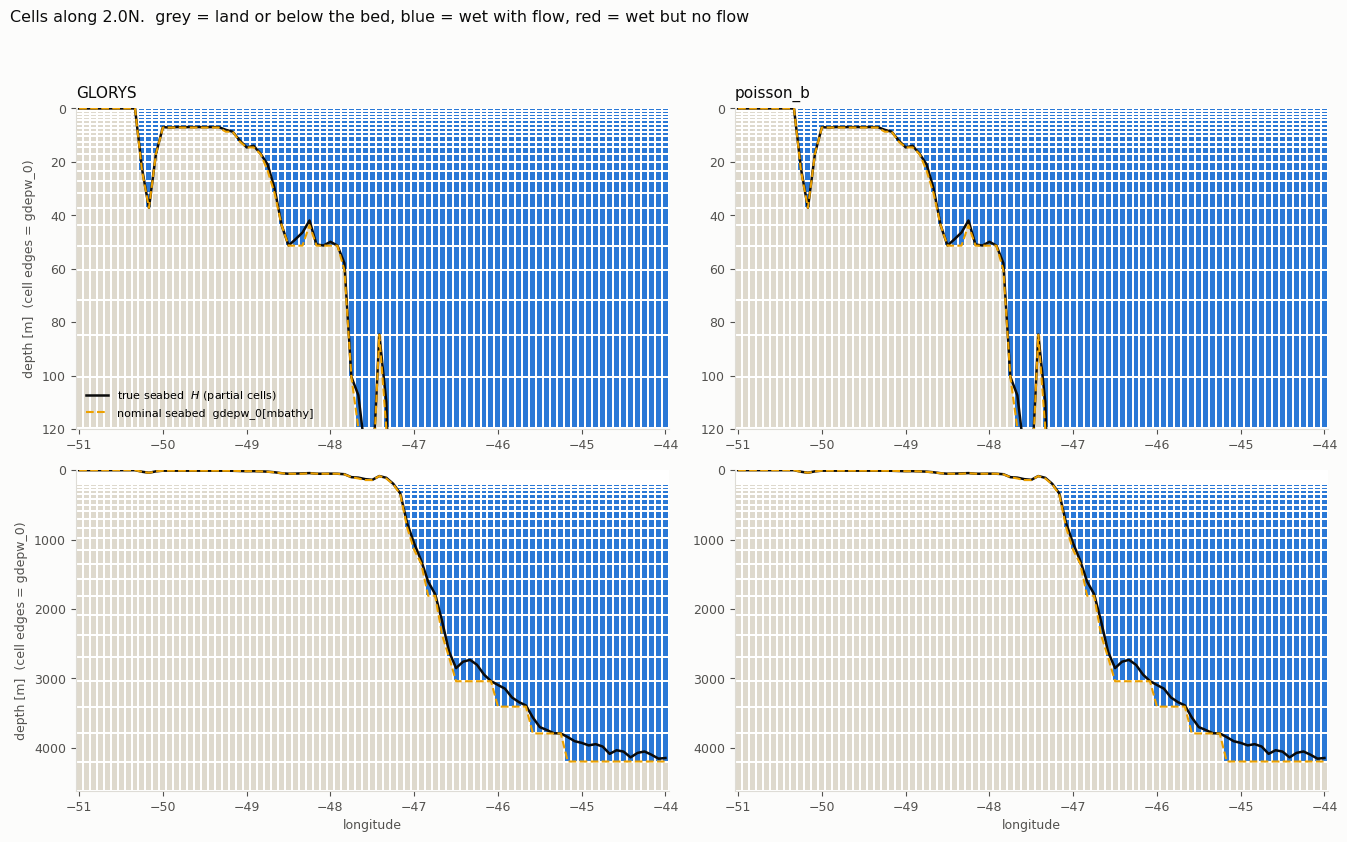

In [6]:
# categorise every cell of the section: 0 land/below bed, 1 wet with flow, 2 wet but dead
def categorise(u, v):
    cat = np.where(wet_t, np.where(live_mask(u, v), 1, 2), 0)
    return cat[:, j, isl]

CMAP = ListedColormap(["#ded9cd", "#2a78d6", "#e34948"])     # land, wet+flow, wet+dead
NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], 3)
dx = np.diff(xlon).mean()
xe = np.concatenate([xlon - dx / 2, [xlon[-1] + dx / 2]])
# gdepw_0 holds the TOP of each cell; pcolormesh needs nz+1 edges, so append the last bottom
zedge = np.append(gdepw_0, gdepw_0[-1] + e3t_0[-1])
zdeep = zedge[int(np.clip(mbathy[j, isl].max() + 1, 0, nz))]

fig, axs = plt.subplots(2, 2, figsize=(13.5, 8.4))
for col, (tag, (u, v, w)) in enumerate(DATA.items()):
    cat = categorise(u, v)
    for row, zmax in enumerate([120, zdeep]):
        ax = axs[row, col]
        ax.pcolormesh(xe, zedge, cat, cmap=CMAP, norm=NORM, shading="flat",
                      edgecolors="#ffffff", linewidth=0.15)
        ax.plot(xlon, H[j, isl], color="#0b0b0b", lw=1.8,
                label="true seabed  $H$ (partial cells)")
        ax.plot(xlon, Hnom[j, isl], color="#eda100", lw=1.5, ls="--",
                label="nominal seabed  gdepw_0[mbathy]")
        ax.set_ylim(zmax, 0)
        if row == 0: ax.set_title(tag, loc="left", fontsize=11, pad=8)
        if row == 1: ax.set_xlabel("longitude")
        if col == 0: ax.set_ylabel("depth [m]  (cell edges = gdepw_0)")
        for s in ("top", "right"): ax.spines[s].set_visible(False)
axs[0, 0].legend(frameon=False, fontsize=8, loc="lower left")
fig.suptitle(f"Cells along {lat2d[j, isl].mean():.1f}N.  "
             "grey = land or below the bed, blue = wet with flow, red = wet but no flow",
             x=0.006, ha="left", fontsize=11.5, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.955])
fig.savefig("wet_cells_transect.png", dpi=170, facecolor=SURF)
plt.show()

## 3. One shelf column, level by level

The same information as a table, for a single column, so the partial cell and the seabed level
are unambiguous.

In [7]:
cand = np.where((H[j, isl] > 25) & (H[j, isl] < 60))[0]
ic = int(np.arange(isl.start, isl.stop)[cand[len(cand) // 2]])
mb = int(mbathy[j, ic])
print(f"column j={j}, i={ic}  ({lon2d[j,ic]:.3f} E, {lat2d[j,ic]:.3f} N)   mbathy = {mb}")
print(f"true seabed H = {H[j,ic]:.2f} m ;  nominal seabed gdepw_0[{mb}] = {gdepw_0[mb]:.2f} m ;"
      f"  bottom cell is {e3t[mb-1,j,ic]:.2f} m of a full {e3t_0[mb-1]:.2f} m\n")
hdr = f"{'k':>3}{'cell top':>10}{'cell bot':>10}{'e3t':>8}{'gdept':>9}  "
for tag in DATA: hdr += f"{tag[:9]+' U':>13}{'W(top)':>11}"
print(hdr)
for k in range(0, min(mb + 3, nz)):
    bot = gdepw_0[k + 1] if k + 1 < nz else np.nan
    row = (f"{k:>3}{gdepw_0[k]:>10.2f}{bot:>10.2f}{e3t[k,j,ic]:>8.2f}{gdept_0[k]:>9.2f}  ")
    for tag, (u, v, w) in DATA.items():
        row += f"{u[k,j,ic]:>13.3e}{w[k,j,ic]:>11.2e}"
    flag = ("  <- deepest wet cell" if k == mb - 1 else
            "  <- seabed level"     if k == mb     else
            "  (below the bed)"     if k > mb      else "")
    print(row + flag)

column j=144, i=561  (-48.250 E, 2.000 N)   mbathy = 17
true seabed H = 41.96 m ;  nominal seabed gdepw_0[17] = 43.70 m ;  bottom cell is 4.73 m of a full 6.43 m

  k  cell top  cell bot     e3t    gdept       GLORYS U     W(top)  poisson_b U     W(top)
  0      0.00      1.01    1.02     0.49     -5.296e-01  -2.50e-06   -5.414e-01   2.03e-20
  1      1.01      2.09    1.07     1.54     -4.849e-01   3.11e-05   -4.965e-01   3.25e-05
  2      2.09      3.22    1.14     2.65     -4.414e-01   6.61e-05   -4.527e-01   6.66e-05
  3      3.22      4.44    1.21     3.82     -4.041e-01   1.02e-04   -4.150e-01   1.02e-04
  4      4.44      5.75    1.31     5.08     -3.749e-01   1.39e-04   -3.855e-01   1.37e-04
  5      5.75      7.17    1.42     6.44     -3.535e-01   1.73e-04   -3.637e-01   1.70e-04
  6      7.17      8.73    1.56     7.93     -3.387e-01   2.02e-04   -3.484e-01   1.99e-04
  7      8.73     10.46    1.73     9.57     -3.256e-01   2.24e-04   -3.348e-01   2.20e-04
  8     10.46     

## 4. Where the dead wet cells are, in the Atlantic

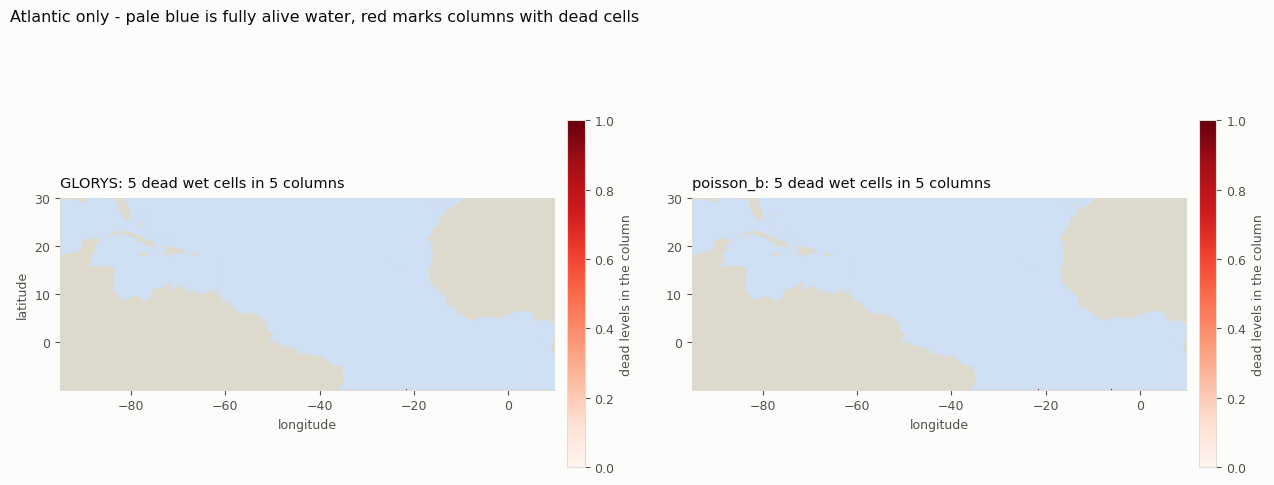

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(13, 5.2))
for ax, (tag, (u, v, w)) in zip(axs, DATA.items()):
    ndead = (wet_t & ~live_mask(u, v)).sum(axis=0).astype(float)
    ndead[~atlantic] = np.nan
    ax.set_facecolor("#ded9cd")
    ax.pcolormesh(lon2d, lat2d, np.where(ndead == 0, 1.0, np.nan),
                  cmap=ListedColormap(["#cfe0f5"]), shading="auto", zorder=0)
    pc = ax.pcolormesh(lon2d, lat2d, np.where(ndead > 0, ndead, np.nan),
                       cmap="Reds", vmin=0, vmax=max(1, np.nanmax(ndead)), shading="auto",
                       zorder=1)
    ax.set_title(f"{tag}: {int(np.nansum(ndead)):,} dead wet cells in "
                 f"{int(np.nansum(ndead > 0)):,} columns", loc="left", fontsize=10.5, pad=8)
    ax.set_xlabel("longitude"); ax.set_aspect(1 / np.cos(np.deg2rad(10)))
    for s in ("top", "right"): ax.spines[s].set_visible(False)
    fig.colorbar(pc, ax=ax, shrink=0.8, pad=0.02, label="dead levels in the column")
axs[0].set_ylabel("latitude")
fig.suptitle("Atlantic only - pale blue is fully alive water, red marks columns with dead cells",
             x=0.006, ha="left", fontsize=11.5, color=INK, y=0.99)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("wet_cells_map.png", dpi=170, facecolor=SURF)
plt.show()

## 5. Full audit - every dead cell in the domain

No region excluded. A dead cell is one the mesh calls water but where the file carries no flow.
Listed exhaustively where the count is small enough to list.

In [9]:
for tag in DATA:
    dead = DEAD[tag]
    interior = dead & ~pacific & ~rim
    print(f"=== {tag} ===")
    print(f"  Pacific  {int((dead & pacific).sum()):>10,} cells in "
          f"{int((dead & pacific).any(axis=0).sum()):>7,} columns")
    print(f"  rim      {int((dead & rim & ~pacific).sum()):>10,} cells in "
          f"{int((dead & rim & ~pacific).any(axis=0).sum()):>7,} columns")
    print(f"  interior {int(interior.sum()):>10,} cells in "
          f"{int(interior.any(axis=0).sum()):>7,} columns")
    if 0 < interior.sum() <= 60:
        kk, jj, ii = np.where(interior)
        for a, b, c_ in zip(kk, jj, ii):
            print(f"      k={a:>2} j={b:>4} i={c_:>5}  ({lon2d[b,c_]:8.3f} E,{lat2d[b,c_]:7.3f} N)"
                  f"  depth {gdept_0[a]:7.1f} m  mbathy={mbathy[b,c_]}  H={H[b,c_]:.1f} m")
    print()

=== GLORYS ===
  Pacific           2 cells in       2 columns
  rim               5 cells in       5 columns
  interior          0 cells in       0 columns

=== poisson_b ===
  Pacific   2,094,765 cells in  49,940 columns


  rim               5 cells in       5 columns
  interior          0 cells in       0 columns



### W separately

W lives on the cell's top face. A column is dead in W only if every wet level is exactly zero.

In [10]:
nwet = wet_t.sum(axis=0)
for tag, (u, v, w) in DATA.items():
    dw = wet_t & (w == 0)
    colw = (dw.sum(axis=0) == nwet) & (nwet > 0)
    print(f"{tag:<11} cells with W == 0 exactly: {int(dw.sum()):>10,}"
          f"   columns dead in W: {int(colw.sum()):>7,}"
          f"   (Pacific {int((colw & (pacific.any() and pacific)).sum() if pacific.any() else 0):>6,},"
          f" rim {int((colw & rim & ~pacific).sum()):>5,},"
          f" interior {int((colw & ~pacific & ~rim).sum()):>4,})")

GLORYS      cells with W == 0 exactly:          0   columns dead in W:       0   (Pacific      0, rim     0, interior    0)


poisson_b   cells with W == 0 exactly:  2,174,759   columns dead in W:  51,686   (Pacific 49,984, rim 1,702, interior    0)


### Where they are

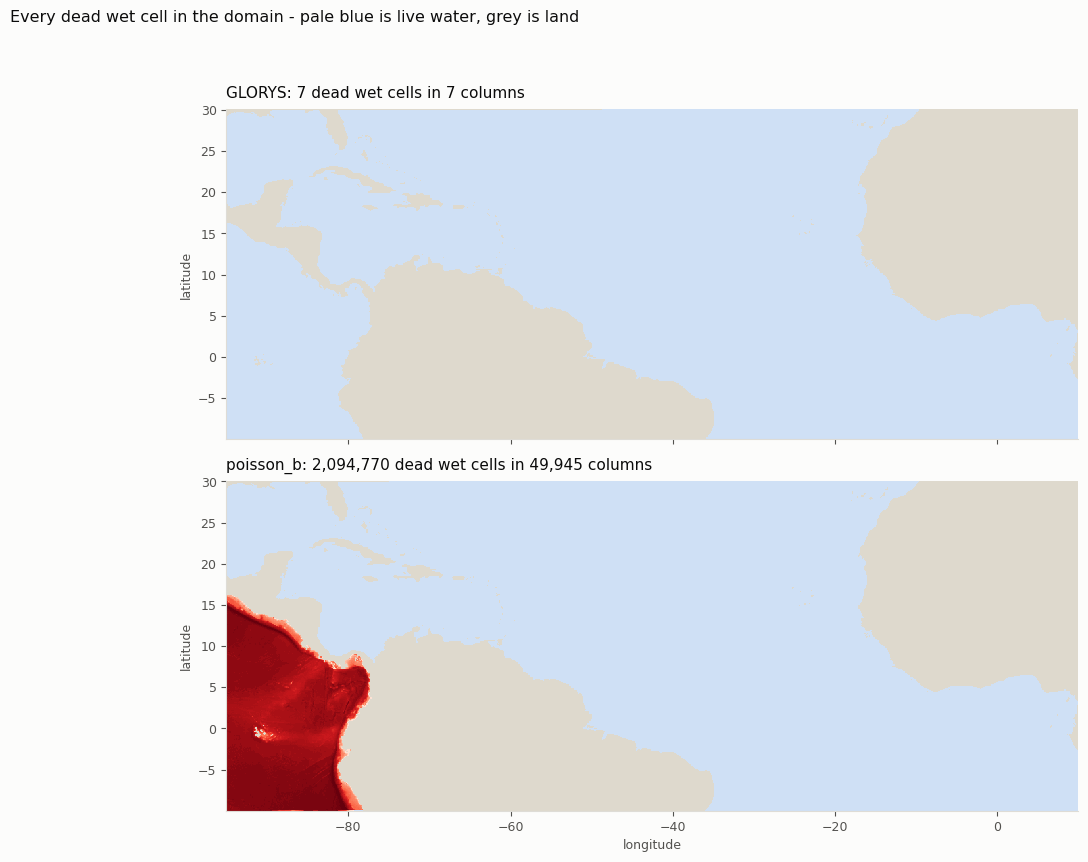

In [11]:
fig, axs = plt.subplots(2, 1, figsize=(13, 8.6), sharex=True, sharey=True)
for ax, tag in zip(axs, DATA):
    ndead = DEAD[tag].sum(axis=0).astype(float)
    ax.set_facecolor("#ded9cd")
    ax.pcolormesh(lon2d, lat2d, np.where((_oc) & (ndead == 0), 1.0, np.nan),
                  cmap=ListedColormap(["#cfe0f5"]), shading="auto", zorder=0)
    m = ndead > 0
    if m.any():
        ax.pcolormesh(lon2d, lat2d, np.where(m, ndead, np.nan), cmap="Reds",
                      vmin=0, vmax=ndead.max(), shading="auto", zorder=1)
    ax.set_title(f"{tag}: {int(ndead.sum()):,} dead wet cells in {int(m.sum()):,} columns",
                 loc="left", fontsize=11, pad=8)
    ax.set_ylabel("latitude"); ax.set_aspect(1 / np.cos(np.deg2rad(10)))
    for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
axs[1].set_xlabel("longitude")
fig.suptitle("Every dead wet cell in the domain - pale blue is live water, grey is land",
             x=0.006, ha="left", fontsize=11.5, color=INK, y=0.995)
fig.tight_layout(rect=[0, 0, 1, 0.955])
# fig.savefig("wet_cells_map_full.png", dpi=170, facecolor=SURF)
plt.show()

### Can a particle actually reach them?

Dead cells only matter to a particle that can get to them. Water bodies that share no face are
unreachable from one another, so this reports, for each basin, whether it holds dead cells.

In [12]:
lab_full = np.full((ny, nx), -1); lab_full[_oc] = _lab
print(f"{'basin':>6}{'columns':>10}{'lon range':>22}   dead cells per file")
for b in range(_n):
    msk = lab_full == b
    if msk.sum() < 50: continue
    line = f"{b:>6}{int(msk.sum()):>10,}   {lon2d[msk].min():7.1f} to {lon2d[msk].max():6.1f}   "
    for tag in DATA:
        line += f"{tag}: {int(DEAD[tag][:, msk].sum()):,}   "
    print(line)
print("\nA particle released in one basin can never enter another - they share no face.")

 basin   columns             lon range   dead cells per file
     0    49,984     -95.0 to  -77.2   GLORYS: 2   poisson_b: 2,094,765   
     1   375,377     -95.0 to    9.9   GLORYS: 5   poisson_b: 5   

A particle released in one basin can never enter another - they share no face.


## 6. The Atlantic dead cells, listed


In [13]:
for tag in DATA:
    d = DEAD[tag] & atlantic
    print(f"{tag}: {int(d.sum())} dead wet cells in the Atlantic "
          f"({int(d.any(axis=0).sum())} columns)")
    kk, jj, ii = np.where(d)
    for a, b, c_ in zip(kk, jj, ii):
        edge = []
        if b == 0: edge.append("j=0 (south edge)")
        if b == ny - 1: edge.append("j=ny-1 (north edge)")
        if c_ == 0: edge.append("i=0 (west edge)")
        if c_ == nx - 1: edge.append("i=nx-1 (east edge)")
        print(f"   k={a:>2} j={b:>4} i={c_:>5}  ({lon2d[b,c_]:8.3f} E,{lat2d[b,c_]:7.3f} N)"
              f"  depth {gdept_0[a]:7.1f} m  mbathy={mbathy[b,c_]:>2}  "
              f"{', '.join(edge) if edge else 'INTERIOR'}")
    print()

GLORYS: 5 dead wet cells in the Atlantic (5 columns)
   k=22 j= 348 i=    0  ( -95.000 E, 18.661 N)  depth   109.7 m  mbathy=23  i=0 (west edge)
   k=43 j=   0 i=  999  ( -11.750 E, -9.950 N)  depth  3220.8 m  mbathy=44  j=0 (south edge)
   k=47 j=   0 i= 1067  (  -6.083 E, -9.950 N)  depth  4833.3 m  mbathy=48  j=0 (south edge)
   k=48 j=   0 i=  875  ( -22.083 E, -9.950 N)  depth  5274.8 m  mbathy=49  j=0 (south edge)
   k=48 j=   0 i=  881  ( -21.583 E, -9.950 N)  depth  5274.8 m  mbathy=49  j=0 (south edge)



poisson_b: 5 dead wet cells in the Atlantic (5 columns)
   k=22 j= 348 i=    0  ( -95.000 E, 18.661 N)  depth   109.7 m  mbathy=23  i=0 (west edge)
   k=43 j=   0 i=  999  ( -11.750 E, -9.950 N)  depth  3220.8 m  mbathy=44  j=0 (south edge)
   k=47 j=   0 i= 1067  (  -6.083 E, -9.950 N)  depth  4833.3 m  mbathy=48  j=0 (south edge)
   k=48 j=   0 i=  875  ( -22.083 E, -9.950 N)  depth  5274.8 m  mbathy=49  j=0 (south edge)
   k=48 j=   0 i=  881  ( -21.583 E, -9.950 N)  depth  5274.8 m  mbathy=49  j=0 (south edge)



## 7. The 5 Atlantic dead cells, pointed out


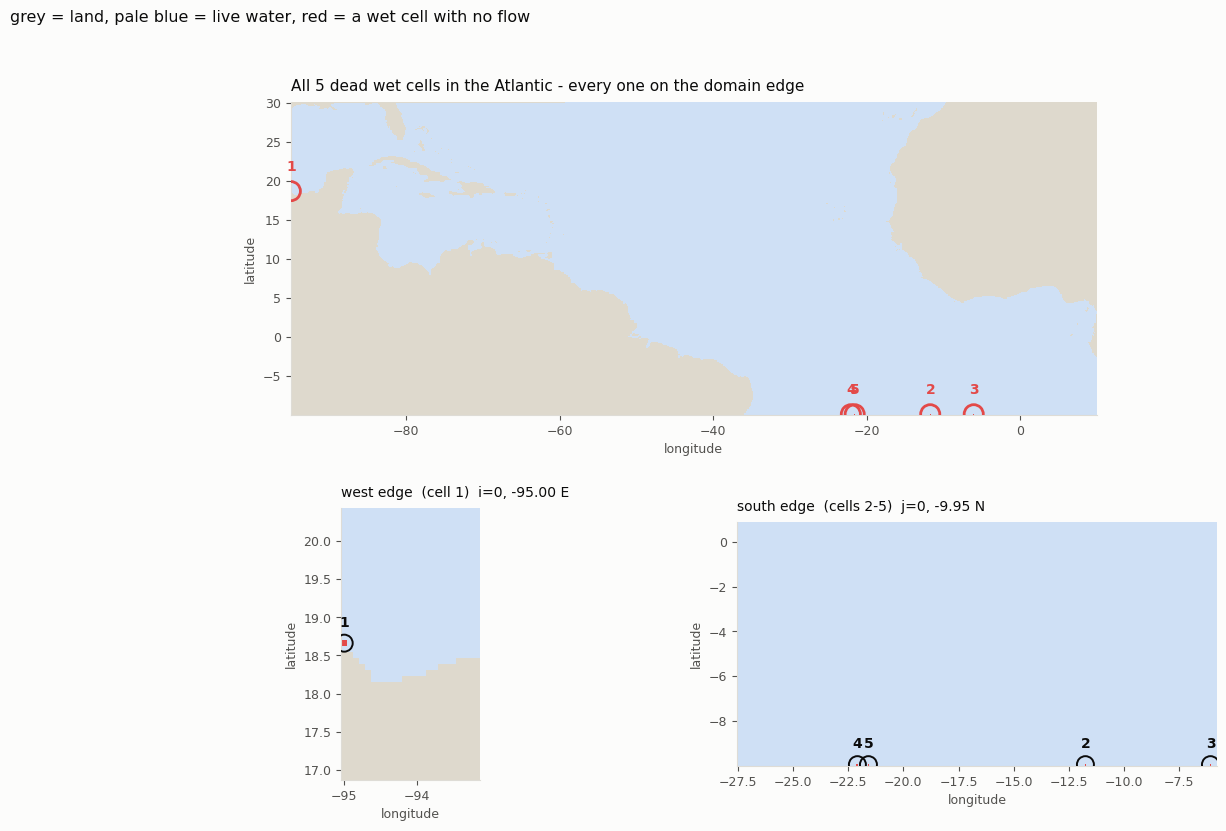

In [14]:
dead_atl = DEAD["GLORYS"] & atlantic
kk, jj, ii = np.where(dead_atl)
ncol = dead_atl.sum(axis=0).astype(float)          # dead cells per column (0 or 1 here)

fig = plt.figure(figsize=(13.5, 8.8))
gs  = fig.add_gridspec(2, 2, height_ratios=[1.15, 1], hspace=0.32, wspace=0.18)

def paint(ax, sl_j, sl_i, cellsize=None):
    """live water pale blue, land grey, dead columns red."""
    LO, LA = lon2d[sl_j, sl_i], lat2d[sl_j, sl_i]
    live = atlantic[sl_j, sl_i] & (ncol[sl_j, sl_i] == 0)
    ax.set_facecolor("#ded9cd")
    ax.pcolormesh(LO, LA, np.where(live, 1.0, np.nan),
                  cmap=ListedColormap(["#cfe0f5"]), shading="auto", zorder=0)
    d = ncol[sl_j, sl_i] > 0
    if d.any():
        ax.pcolormesh(LO, LA, np.where(d, 1.0, np.nan),
                      cmap=ListedColormap(["#e34948"]), shading="auto", zorder=2)
    for s_ in ("top", "right"): ax.spines[s_].set_visible(False)

# --- A: whole Atlantic, with the five marked -------------------------------------------
axA = fig.add_subplot(gs[0, :])
paint(axA, slice(None), slice(None))
axA.scatter(lon2d[jj, ii], lat2d[jj, ii], s=190, facecolor="none", edgecolor="#e34948",
            linewidth=2.0, zorder=5)
for n, (a, b, c_) in enumerate(zip(kk, jj, ii)):
    axA.annotate(f"{n+1}", (lon2d[b, c_], lat2d[b, c_]), xytext=(0, 15),
                 textcoords="offset points", ha="center", fontsize=10,
                 fontweight="bold", color="#e34948", zorder=6)
axA.set_aspect(1 / np.cos(np.deg2rad(10)))
axA.set_xlabel("longitude"); axA.set_ylabel("latitude")
axA.set_title(f"All {len(kk)} dead wet cells in the Atlantic - every one on the domain edge",
              loc="left", fontsize=11, pad=8)

# --- B, C: zooms --------------------------------------------------------------------
for ax, (jc, ic, half, ttl) in zip(
        [fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1])],
        [(jj[0], ii[0], 22, f"west edge  (cell 1)  i=0, {lon2d[jj[0],ii[0]]:.2f} E"),
         (0, int(np.median(ii[1:])), 130, "south edge  (cells 2-5)  j=0, -9.95 N")]):
    sj = slice(max(0, jc - half), min(ny, jc + half + 1))
    si = slice(max(0, ic - half), min(nx, ic + half + 1))
    paint(ax, sj, si)
    sel = (jj >= sj.start) & (jj < sj.stop) & (ii >= si.start) & (ii < si.stop)
    ax.scatter(lon2d[jj[sel], ii[sel]], lat2d[jj[sel], ii[sel]], s=150, facecolor="none",
               edgecolor="#0b0b0b", linewidth=1.4, zorder=6)
    for n, (b, c_) in enumerate(zip(jj, ii)):
        if sel[n]:
            ax.annotate(f"{n+1}", (lon2d[b, c_], lat2d[b, c_]), xytext=(0, 12),
                        textcoords="offset points", ha="center", fontsize=10,
                        fontweight="bold", color="#0b0b0b", zorder=7)
    ax.set_aspect(1 / np.cos(np.deg2rad(abs(lat2d[jc, ic]))))
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude")
    ax.set_title(ttl, loc="left", fontsize=10, pad=8)

fig.suptitle("grey = land, pale blue = live water, red = a wet cell with no flow",
             x=0.006, ha="left", fontsize=11.5, color=INK, y=0.985)
fig.savefig("wet_cells_dead_atlantic.png", dpi=170, facecolor=SURF, bbox_inches="tight")
plt.show()

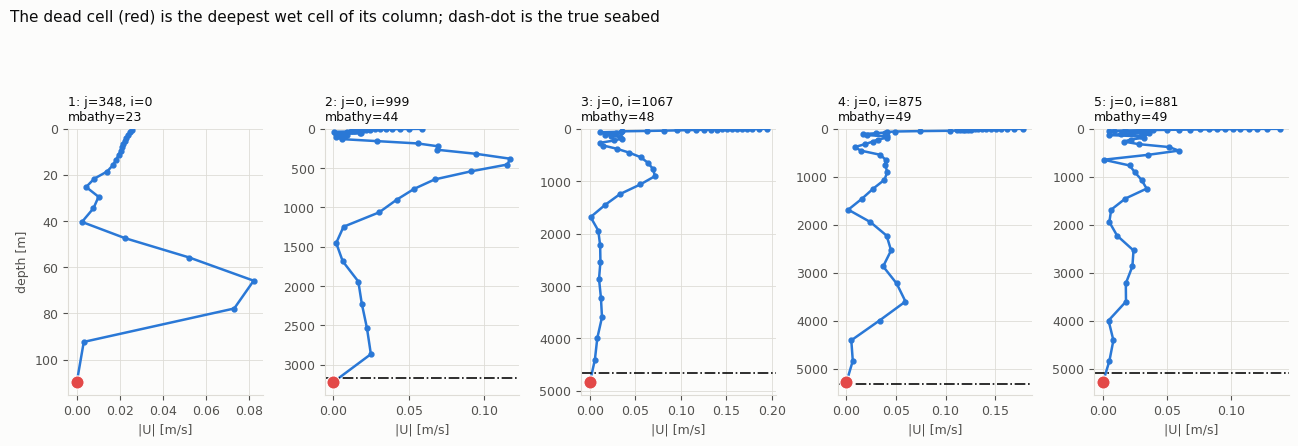

In [15]:
# and the columns themselves: only the bottom cell is dead
u_g = DATA["GLORYS"][0]
fig, axs = plt.subplots(1, len(kk), figsize=(2.6 * len(kk), 4.4), sharey=False)
for n, (a, b, c_, ax) in enumerate(zip(kk, jj, ii, np.atleast_1d(axs))):
    mb = int(mbathy[b, c_])
    prof = np.abs(u_g[:mb, b, c_])
    ax.plot(prof, gdept_0[:mb], lw=1.8, color="#2a78d6", marker="o", ms=3.5)
    ax.scatter([prof[a]], [gdept_0[a]], s=90, facecolor="#e34948",
               edgecolor="white", zorder=5, linewidth=0.8)
    ax.axhline(H[b, c_], color="#0b0b0b", lw=1.2, ls="-.")
    ax.set_ylim(gdept_0[mb - 1] * 1.05, 0)
    ax.set_title(f"{n+1}: j={b}, i={c_}\nmbathy={mb}", loc="left", fontsize=9, pad=6)
    ax.set_xlabel("|U| [m/s]")
    if n == 0: ax.set_ylabel("depth [m]")
    ax.grid(True, lw=0.6, color=GRID); ax.set_axisbelow(True)
    for s_ in ("top", "right"): ax.spines[s_].set_visible(False)
fig.suptitle("The dead cell (red) is the deepest wet cell of its column; "
             "dash-dot is the true seabed", x=0.006, ha="left", fontsize=11, color=INK, y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.9])
fig.savefig("wet_cells_dead_profiles.png", dpi=170, facecolor=SURF, bbox_inches="tight")
plt.show()